In [32]:
# standard library
import os
import glob
import random
from collections import Counter

# data handling
import pandas as pd

# image processing
from PIL import Image
import cv2

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# deep learning
import torch
from facenet_pytorch import MTCNN

# utilities
from tqdm import tqdm

In [33]:
classes = ['realperson', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_mannequin', 'fake_unknown']

TRAIN_PATH_RAW = "../data/train"
TRAIN_PATH = "../data/cropped"
TEST_PATH  = "../data/cropped_test"

## <b>1) overview clean dataset</b>
> - data train didominasi oleh kelas fake (~73%) imbalance <br>
> - format gambar didominasi oleh .jpg di train dan test

### <h4 style="color:blue;">Visual Inspect</h5>

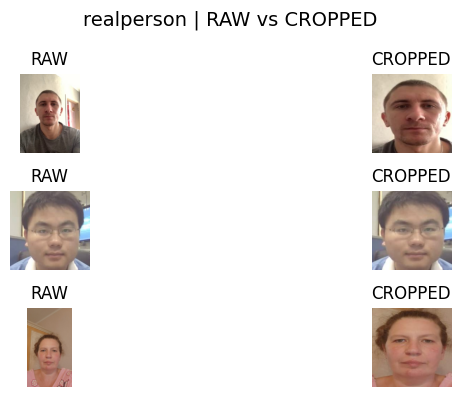

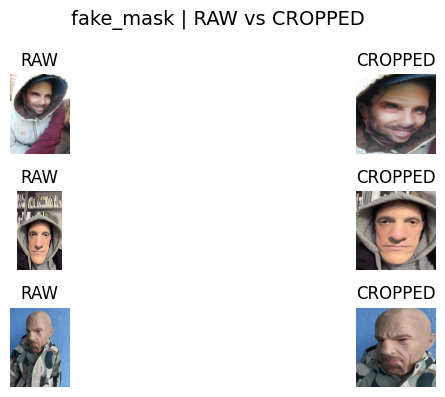

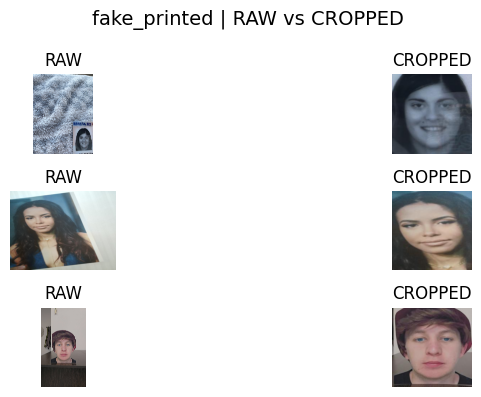

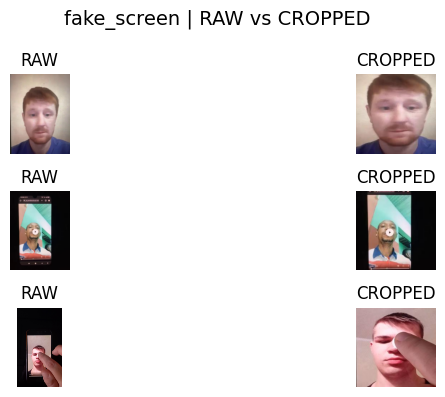

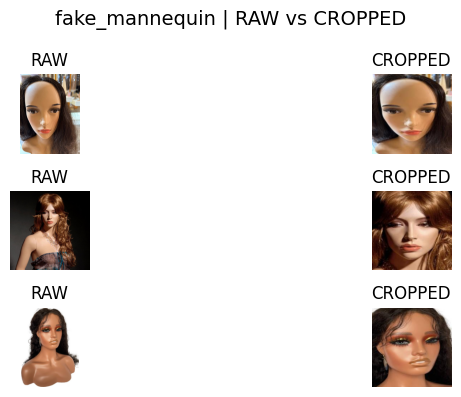

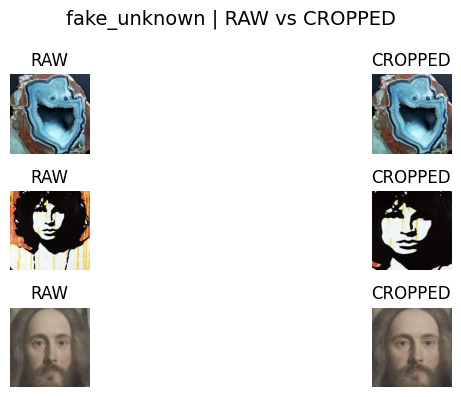

In [17]:
SAMPLES_PER_CLASS = 3

for cls in classes:
    raw_dir  = os.path.join(TRAIN_PATH_RAW, cls)
    crop_dir = os.path.join(TRAIN_PATH, cls)

    if not os.path.exists(raw_dir) or not os.path.exists(crop_dir):
        print(f"Skip {cls} (folder tidak lengkap)")
        continue

    raw_files = [f for f in os.listdir(raw_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    crop_files = [f for f in os.listdir(crop_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]

    if len(raw_files) == 0 or len(crop_files) == 0:
        print(f"Skip {cls} (no images)")
        continue

    # ambil sample random dari RAW (biar match nama file)
    sampled = random.sample(raw_files, min(SAMPLES_PER_CLASS, len(raw_files)))

    plt.figure(figsize=(10, 4))
    plt.suptitle(f"{cls} | RAW vs CROPPED", fontsize=14)

    for i, file in enumerate(sampled):
        raw_path  = os.path.join(raw_dir, file)
        crop_path = os.path.join(crop_dir, file)

        # kalau file hasil crop tidak ada, skip
        if not os.path.exists(crop_path):
            continue

        try:
            img_raw  = Image.open(raw_path)
            img_crop = Image.open(crop_path)

            # RAW
            plt.subplot(SAMPLES_PER_CLASS, 2, 2*i + 1)
            plt.imshow(img_raw)
            plt.title("RAW")
            plt.axis('off')

            # CROPPED
            plt.subplot(SAMPLES_PER_CLASS, 2, 2*i + 2)
            plt.imshow(img_crop)
            plt.title("CROPPED")
            plt.axis('off')

        except:
            continue

    plt.tight_layout()
    plt.show()

### <h4 style="color:blue;">Distribusi Kelas: Fake vs Real</h5>

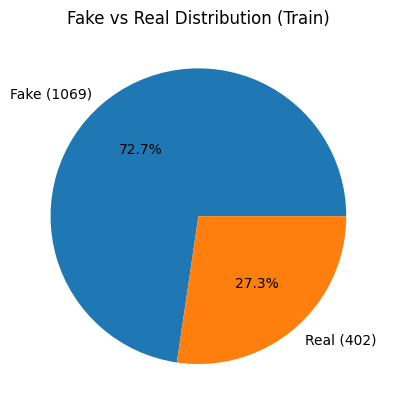

Total rows: 1471


In [7]:
def count_images(base_path):
    counts = {}
    
    for cls in classes:
        folder = os.path.join(base_path, cls)
        
        if not os.path.exists(folder):
            counts[cls] = 0
            continue
        
        counts[cls] = len(os.listdir(folder))
    
    return counts

# ambil dari TRAIN
counts = count_images(TRAIN_PATH)

real = counts['realperson']
fake = sum([counts[c] for c in classes if c != 'realperson'])

labels = [f'Fake ({fake})', f'Real ({real})']
sizes = [fake, real]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Fake vs Real Distribution (Train)')
plt.show()

print("Total rows:", fake + real)

### <h4 style="color:blue;">Distribusi Format File pada Dataset (Train vs Test)</h5>

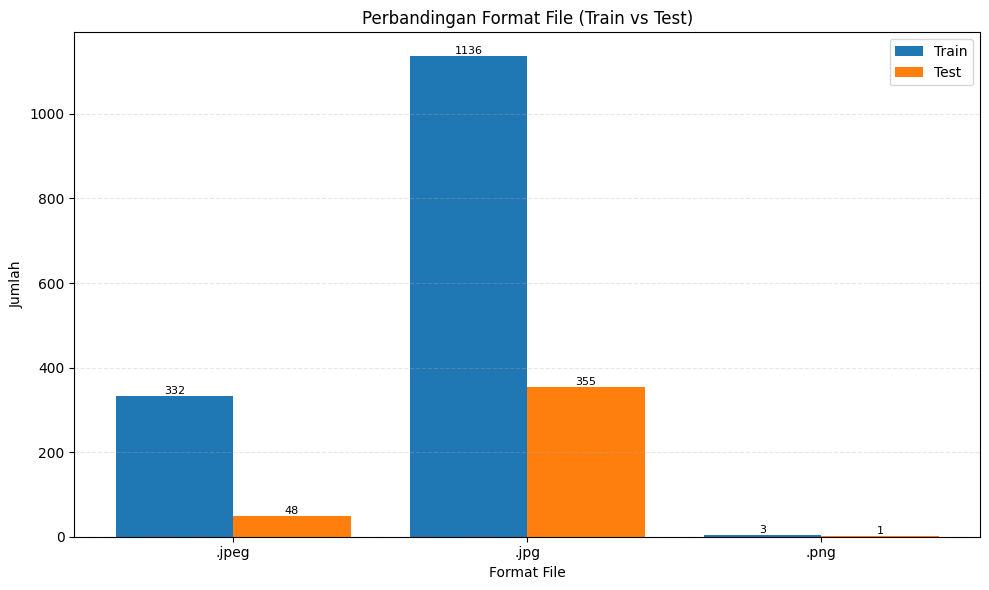

In [8]:
# ada format apa aja?

def count_formats(directory):
    counter = Counter()
    
    for root, _, files in os.walk(directory):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext:  # skip kalau ga ada extension
                counter[ext] += 1
                
    return counter

# hitung
train_formats = count_formats(TRAIN_PATH)
test_formats  = count_formats(TEST_PATH)

all_formats = sorted(set(train_formats) | set(test_formats))

train_counts = [train_formats.get(f, 0) for f in all_formats]
test_counts  = [test_formats.get(f, 0) for f in all_formats]

x = range(len(all_formats))
width = 0.4

# plot
plt.figure(figsize=(10, 6))

bars1 = plt.bar([i - width/2 for i in x], train_counts, width, label='Train')
bars2 = plt.bar([i + width/2 for i in x], test_counts,  width, label='Test')

plt.xticks(x, all_formats)
plt.xlabel("Format File")
plt.ylabel("Jumlah")
plt.title("Perbandingan Format File (Train vs Test)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# label angka
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h, str(int(h)),
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### <h4 style="color:blue;">Resolusi dan Distribusi Gambar per Kelas Dataset Training (Clean)</h5>

In [ ]:
def analyze_image_resolution_by_class(base_path, classes):
    size_counter = Counter()
    unique_sizes = set()
    total_images = 0
    error_count = 0

    print("Distribusi Label:")
    print("---------------")

    for cls in classes:
        class_path = os.path.join(base_path, cls)
        
        if not os.path.exists(class_path):
            print(f"{cls}: folder tidak ditemukan")
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"{cls}: {len(images)}")
        
        total_images += len(images)

        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            
            try:
                with Image.open(img_path) as img:
                    size = img.size
                    unique_sizes.add(size)
                    size_counter[size] += 1
            except:
                error_count += 1

    print("---------------")
    
    print("Unique Resolutions:")
    for size in sorted(unique_sizes):
        print(f"- {size}")

    print("---------------")

    print("Top 5 Most Common Resolutions:")
    for size, count in size_counter.most_common(5):
        print(f"- {size}: {count} images")

    print("---------------")
    print(f"Total images : {total_images}")
    print(f"Error images : {error_count}")

print("\nChecking image resolutions (Train Set):")
analyze_image_resolution_by_class(TRAIN_PATH, classes)


Checking image resolutions (Train Set):
Distribusi Label:
---------------
realperson: 402
fake_mask: 254
fake_printed: 104
fake_screen: 196
fake_mannequin: 197
fake_unknown: 318
---------------
Unique Resolutions:
- (224, 224)
---------------
Top 5 Most Common Resolutions:
- (224, 224): 1471 images
---------------
Total images : 1471
Error images : 0


## <b>2) data quality dan structure</b>
> - cropping tidak mengubah brightness secara signifikan, tetapi menurunkan contrast (lebih homogen)<br>
> - distribusi RGB setelah cropping lebih terstruktur, menandakan fokus ke area wajah<br>
> - antar kelas masih sangat overlap, sehingga sulit dipisahkan hanya dari brightness & contrast

> <b>Tekankan augmentasi yang memperkaya tekstur dan artefak wajah, karena brightness/contrast tidak cukup membedakan kelas.

### <h4 style="color:blue;">Resolusi Gambar Hasil Cropping pada Dataset Training</h5>

Train files: 600
Crop files : 600
Valid Train: 500
Valid Crop : 500
Rata-rata Kecerahan (Train): 119.55
Rata-rata Kecerahan (Crop):  119.99
Rata-rata Kontras (Train):   60.28
Rata-rata Kontras (Crop):    54.01


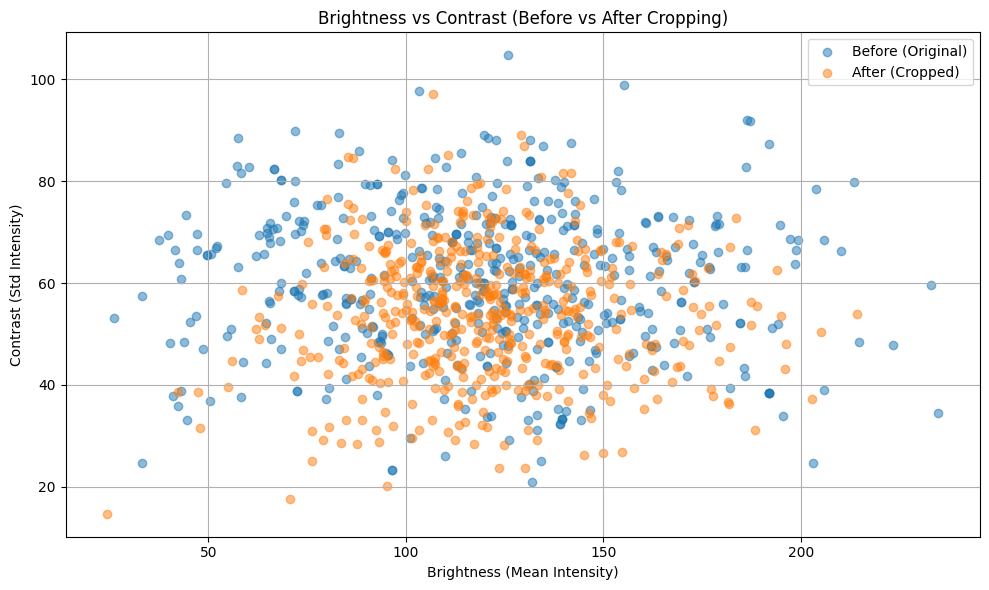

In [36]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

VALID_EXT = ('.jpg', '.jpeg', '.png')

def get_brightness_contrast(image_paths, max_samples=500):
    brightness = []
    contrast = []

    image_paths = image_paths[:max_samples]

    for img_path in image_paths:
        if not img_path.lower().endswith(VALID_EXT):
            continue

        try:
            # ✅ pakai PIL (lebih stabil dari cv2)
            img = Image.open(img_path).convert("L")  # grayscale
            img = np.array(img)

            brightness.append(np.mean(img))
            contrast.append(np.std(img))

        except:
            continue

    return brightness, contrast


def collect_images(base_path, classes, max_per_class=100):
    all_files = []

    for cls in classes:
        class_path = os.path.join(base_path, cls)

        if not os.path.exists(class_path):
            continue

        files = [
            f for f in glob.glob(os.path.join(class_path, '*'))
            if f.lower().endswith(VALID_EXT)
        ][:max_per_class]

        all_files.extend(files)

    return all_files


def safe_mean(arr):
    return np.mean(arr) if len(arr) > 0 else 0


# ===== ambil data =====
train_image_files = collect_images(TRAIN_PATH_RAW, classes)
crop_image_files  = collect_images(TRAIN_PATH, classes)

print("Train files:", len(train_image_files))
print("Crop files :", len(crop_image_files))


# ===== hitung =====
train_b, train_c = get_brightness_contrast(train_image_files)
crop_b, crop_c   = get_brightness_contrast(crop_image_files)

print("Valid Train:", len(train_b))
print("Valid Crop :", len(crop_b))


# ===== statistik =====
print(f"Rata-rata Kecerahan (Train): {safe_mean(train_b):.2f}")
print(f"Rata-rata Kecerahan (Crop):  {safe_mean(crop_b):.2f}")
print(f"Rata-rata Kontras (Train):   {safe_mean(train_c):.2f}")
print(f"Rata-rata Kontras (Crop):    {safe_mean(crop_c):.2f}")


# ===== visualisasi =====
plt.figure(figsize=(10, 6))

if len(train_b) > 0:
    plt.scatter(train_b, train_c, alpha=0.5, label='Before (Original)')

if len(crop_b) > 0:
    plt.scatter(crop_b, crop_c, alpha=0.5, label='After (Cropped)')

plt.title('Brightness vs Contrast (Before vs After Cropping)')
plt.xlabel('Brightness (Mean Intensity)')
plt.ylabel('Contrast (Std Intensity)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### <h4 style="color:blue;">Pemetaan Brightness vs Contrast per Kelas pada Gambar Hasil Cropping</h5>

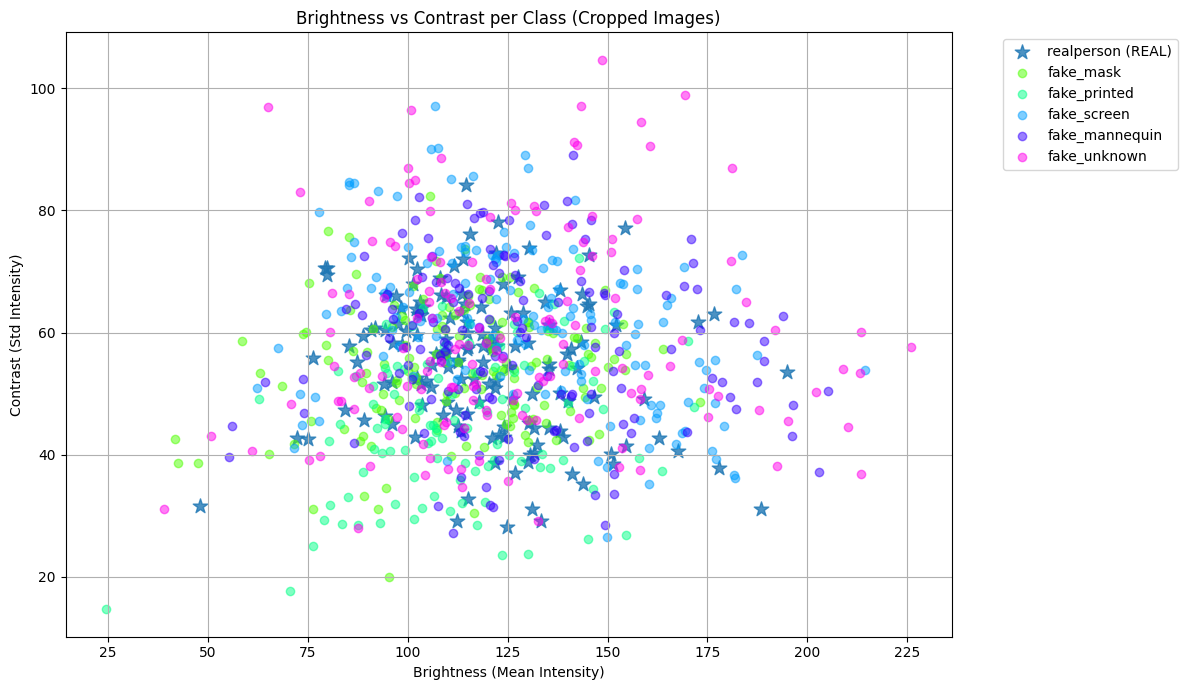

In [ ]:
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt

VALID_EXT = ('.jpg', '.jpeg', '.png')

plt.figure(figsize=(12, 7))

palette = sns.color_palette("hsv", len(classes))

for idx, cls in enumerate(classes):
    class_path = os.path.join(TRAIN_PATH, cls)  # ✅ fix path

    if not os.path.exists(class_path):
        print(f"Skip {cls} (folder tidak ada)")
        continue

    cls_paths = [
        f for f in glob.glob(os.path.join(class_path, '*'))
        if f.lower().endswith(VALID_EXT)
    ][:150]

    if len(cls_paths) == 0:
        print(f"No images in {cls}")
        continue

    b, c = get_brightness_contrast(cls_paths)

    if len(b) == 0:
        print(f"No valid images in {cls}")
        continue

    # highlight realperson
    if cls == 'realperson':
        plt.scatter(b, c, alpha=0.8, marker='*', s=120, label='realperson (REAL)')
    else:
        plt.scatter(b, c, alpha=0.5, color=palette[idx], label=cls)

plt.title('Brightness vs Contrast per Class (Cropped Images)')
plt.xlabel('Brightness (Mean Intensity)')
plt.ylabel('Contrast (Std Intensity)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

### <h4 style="color:blue;">Perbandingan Distribusi Warna RGB Sebelum dan Sesudah Cropping</h5>

Train files: 600
Crop files : 600


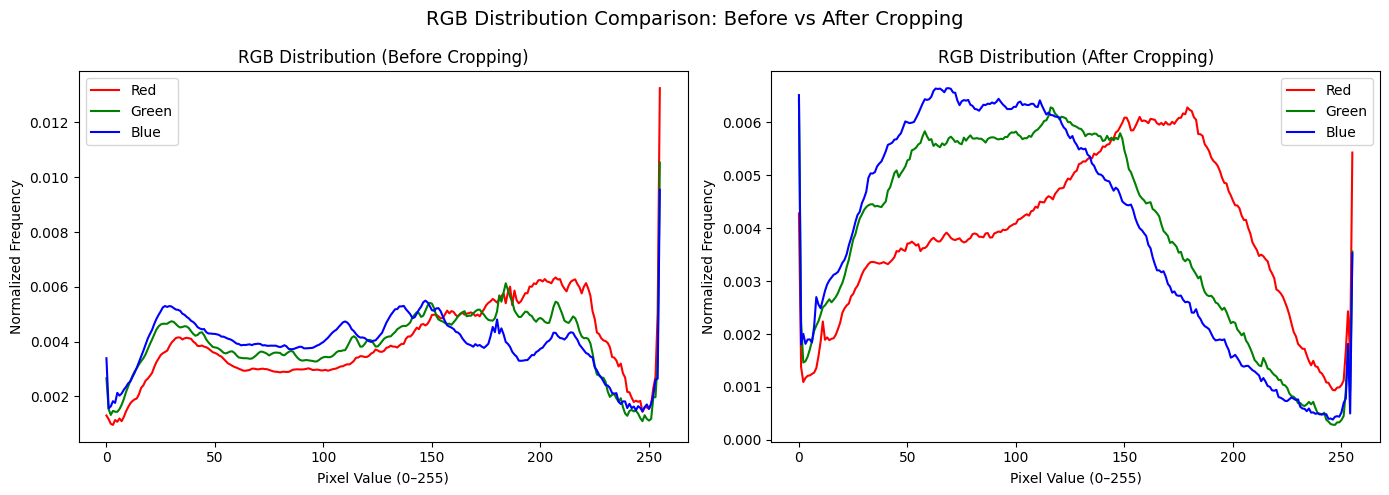

In [30]:
VALID_EXT = ('.jpg', '.jpeg', '.png')


def get_average_rgb_histogram(image_paths, max_samples=300):
    avg_hist = np.zeros((256, 3))
    valid_count = 0

    image_paths = image_paths[:max_samples]

    for img_path in image_paths:
        if not img_path.lower().endswith(VALID_EXT):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        for i in range(3):  # R, G, B
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            avg_hist[:, i] += hist.flatten()

        valid_count += 1

    if valid_count > 0:
        avg_hist /= valid_count

        # normalisasi jadi distribusi
        for i in range(3):
            s = np.sum(avg_hist[:, i])
            if s > 0:
                avg_hist[:, i] /= s

    return avg_hist


def collect_images(base_path, classes, max_per_class=100):
    all_files = []

    for cls in classes:
        class_path = os.path.join(base_path, cls)

        if not os.path.exists(class_path):
            continue

        files = [
            f for f in glob.glob(os.path.join(class_path, '*'))
            if f.lower().endswith(VALID_EXT)
        ][:max_per_class]

        all_files.extend(files)

    return all_files


# ===== ambil data =====
train_image_files = collect_images(TRAIN_PATH_RAW, classes)
crop_image_files  = collect_images(TRAIN_PATH, classes)

print("Train files:", len(train_image_files))
print("Crop files :", len(crop_image_files))


# ===== hitung histogram =====
hist_train = get_average_rgb_histogram(train_image_files)
hist_crop  = get_average_rgb_histogram(crop_image_files)


# ===== visualisasi =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['red', 'green', 'blue']

# TRAIN (RAW)
for i, col in enumerate(colors):
    axes[0].plot(hist_train[:, i], color=col, label=col.capitalize())

axes[0].set_title('RGB Distribution (Before Cropping)')
axes[0].set_xlabel('Pixel Value (0–255)')
axes[0].set_ylabel('Normalized Frequency')
axes[0].legend()


# CROPPED
for i, col in enumerate(colors):
    axes[1].plot(hist_crop[:, i], color=col, label=col.capitalize())

axes[1].set_title('RGB Distribution (After Cropping)')
axes[1].set_xlabel('Pixel Value (0–255)')
axes[1].set_ylabel('Normalized Frequency')
axes[1].legend()


plt.suptitle('RGB Distribution Comparison: Before vs After Cropping', fontsize=14)

plt.tight_layout()
plt.show()